Question 1

Polynomial Features for Mobile Phone Prices

In [2]:
import pandas as pd 
from sklearn.preprocessing import PolynomialFeatures 
data = { "RAM": [4, 6, 8, 12], "Storage": [64, 128, 128, 256] } 
df = pd.DataFrame(data) 
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(df) 
print(X_poly)

[[1.0000e+00 4.0000e+00 6.4000e+01 1.6000e+01 2.5600e+02 4.0960e+03]
 [1.0000e+00 6.0000e+00 1.2800e+02 3.6000e+01 7.6800e+02 1.6384e+04]
 [1.0000e+00 8.0000e+00 1.2800e+02 6.4000e+01 1.0240e+03 1.6384e+04]
 [1.0000e+00 1.2000e+01 2.5600e+02 1.4400e+02 3.0720e+03 6.5536e+04]]


Question 2

Linear Regression vs Polynomial Regression

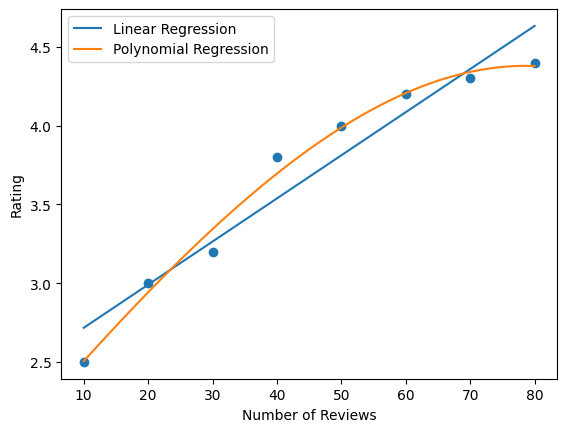

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures 

reviews = np.array([10, 20, 30, 40, 50, 60, 70, 80]).reshape(-1, 1) 

ratings = np.array([2.5, 3.0, 3.2, 3.8, 4.0, 4.2, 4.3, 4.4]) 

linear_model = LinearRegression() 

linear_model.fit(reviews, ratings) 

poly = PolynomialFeatures(degree=3) 
reviews_poly = poly.fit_transform(reviews) 
poly_model = LinearRegression() 
poly_model.fit(reviews_poly, ratings) 
x_range = np.linspace(10, 80, 100).reshape(-1, 1) 
plt.scatter(reviews, ratings) 
plt.plot( x_range, linear_model.predict(x_range), label="Linear Regression" ) 
plt.plot( x_range, poly_model.predict(poly.transform(x_range)), label="Polynomial Regression" ) 
plt.xlabel("Number of Reviews") 
plt.ylabel("Rating") 
plt.legend() 
plt.show()

Question 3

Checking Overfitting Using Polynomial Regression

C:\Users\Aaryan\AppData\Local\Temp\ipykernel_4220\4131656465.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


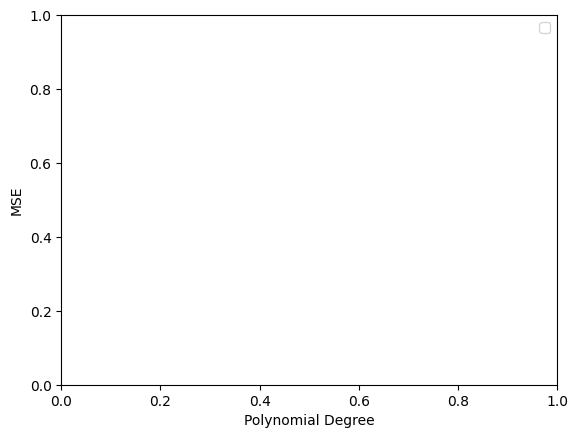

In [16]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error 

X = np.arange(1, 31).reshape(-1, 1) 
y = np.array([ 5, 7, 8, 10, 13, 16, 18, 21, 24, 27, 30, 33, 37, 40, 44, 48, 52, 56, 60, 64, 69, 74, 79, 84, 89, 95, 101, 107, 113, 120 ]) 
X_train, X_val, y_train, y_val = train_test_split( X, y, test_size=0.3, random_state=42 ) 
train_errors = [] 
val_errors = [] 
for degree in range(1, 6):
 Poly = PolynomialFeatures(degree=degree) 
X_train_poly = poly.fit_transform(X_train) 
X_val_poly = poly.transform(X_val) 
model = LinearRegression() 
model.fit(X_train_poly, y_train) 
train_pred = model.predict(X_train_poly) 
val_pred = model.predict(X_val_poly) 
train_errors.append( mean_squared_error(y_train, train_pred) ) 
val_errors.append( mean_squared_error(y_val, val_pred) ) 
plt.xlabel("Polynomial Degree") 
plt.ylabel("MSE") 
plt.legend() 
plt.show()

Question 4

Polynomial Regression with Ridge Regularization

In [19]:
from sklearn.linear_model import Ridge 
from sklearn.metrics import mean_squared_error 
poly = PolynomialFeatures(degree=3) 
X_poly = poly.fit_transform(reviews) 
normal_model = LinearRegression() 
normal_model.fit(X_poly, ratings) 
normal_pred = normal_model.predict(X_poly) 
ridge_model = Ridge(alpha=1.0) 
ridge_model.fit(X_poly, ratings) 
ridge_pred = ridge_model.predict(X_poly) 
print( "Polynomial Regression MSE:", 
mean_squared_error(ratings, normal_pred) ) 
print( "Ridge Regression MSE:", mean_squared_error(ratings, ridge_pred) )

Polynomial Regression MSE: 0.004637445887445872
Ridge Regression MSE: 0.0046498906966478


Question 5

Underfitting and Overfitting Example

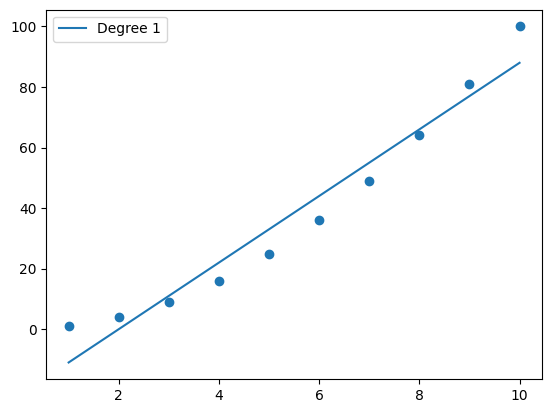

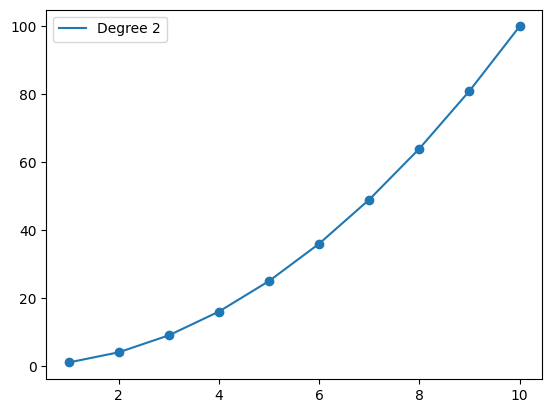

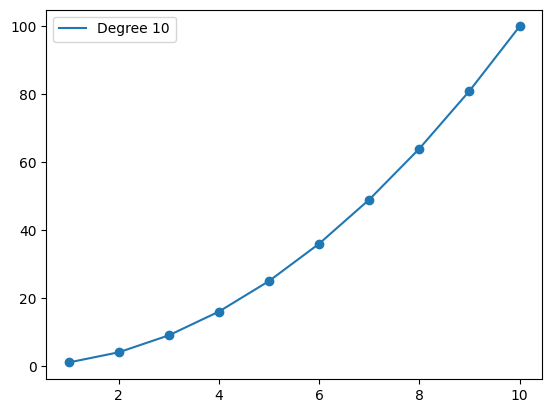

In [20]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1) 
y = np.array([1,4,9,16,25,36,49,64,81,100]) 
for degree in [1, 2, 10]: 
    poly = PolynomialFeatures(degree=degree) 
    X_poly = poly.fit_transform(X) 
    model = LinearRegression() 
    model.fit(X_poly, y) 
    plt.scatter(X, y) 
    plt.plot( X, model.predict(X_poly), 
    label=f"Degree {degree}" ) 
    plt.legend() 
    plt.show()